In [1]:
# Cell 1 — imports and load data
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from wordcloud import WordCloud

df = pd.read_csv("E:/Research Paper topic/data/processed_papers.csv")
topic_info = pd.read_csv("E:/Research Paper topic/data/topic_info.csv")
df_clean = df[df['topic'] >= 0].copy()
df_clean['year'] = pd.to_numeric(df_clean['year'], errors='coerce')

print("Loaded:", df_clean.shape)
print("Topics found:", df_clean['topic'].nunique())
topic_info.head(10)

Loaded: (220, 12)
Topics found: 8


,Topic,Count,Name,Representation,Representative_Docs
0,-1,80,-1_learning_policy_reinforcement_model,"['learning', 'policy', 'reinforcement', 'model...",['navol navigation policy online imitation lea...
1,0,37,0_policy_learning_task_reinforcement learning,"['policy', 'learning', 'task', 'reinforcement ...",['rankq offlinetoonline reinforcement learning...
2,1,36,1_model_task_reasoning_manipulation,"['model', 'task', 'reasoning', 'manipulation',...",['expoft sampleefficient reinforcement learnin...
3,2,34,2_driving_learning_autonomous_safety,"['driving', 'learning', 'autonomous', 'safety'...",['reap reinforcementlearning endtoend autonomo...
4,3,33,3_locomotion_motion_robot_learning,"['locomotion', 'motion', 'robot', 'learning', ...",['parkourformer integrating predictive supervi...
5,4,29,4_control_learning_flight_policy,"['control', 'learning', 'flight', 'policy', 'q...",['aerial inspection behavior via rlbased quadr...
6,5,23,5_communication_learning_robot_task,"['communication', 'learning', 'robot', 'task',...",['scalecomm shared contrastivelyaligned latent...
7,6,14,6_tactile_object_manipulation_learning,"['tactile', 'object', 'manipulation', 'learnin...",['learning tactileaware quadrupedal locomanipu...
8,7,14,7_control_policy_gradient_optimization,"['control', 'policy', 'gradient', 'optimizatio...",['learning hybridcontrol policy highprecision ...


In [2]:
# Cell — add topic names to dataframe
topic_names = {
    0: "Offline Reinforcement Learning",
    1: "Vision-Language-Action Models",
    2: "Autonomous Driving",
    3: "Humanoid Robot Locomotion",
    4: "UAV / Drone Control",
    5: "Multi-Agent Robotics",
    6: "Dexterous Manipulation",
    7: "Policy Optimization Methods"
}

df_clean['topic_name'] = df_clean['topic'].map(topic_names)
df_clean.to_csv("E:/Research Paper topic/data/processed_papers.csv", index=False)
print("Topic names added!")
df_clean[['title', 'topic', 'topic_name']].head(10)

Topic names added!


,title,topic,topic_name
0,BORA: Bridging Offline Reinforcement Learning ...,0,Offline Reinforcement Learning
1,Sample-Efficient Diffusion-based Reinforcement...,0,Offline Reinforcement Learning
2,LLM-Guided Future Hypotheses for Horizon-Aware...,1,Vision-Language-Action Models
3,Momentum Based Reward Design for Low Emission ...,2,Autonomous Driving
4,VE2VF: Vision-Enabled to Vision-Free Distillat...,1,Vision-Language-Action Models
6,Beyond Binary: Sim-to-Real Dexterous Manipulat...,6,Dexterous Manipulation
7,SARAD: LLM-Based Safety-Aware Hybrid Reinforce...,2,Autonomous Driving
8,Learning a Kinodynamic Trajectory Manifold for...,4,UAV / Drone Control
10,ProgVLA: Progress-Aware Robot Manipulation Ski...,1,Vision-Language-Action Models
11,Visualizing Latent Phase Structures in Locomot...,3,Humanoid Robot Locomotion


In [3]:
df_clean = pd.read_csv("E:/Research Paper topic/data/processed_papers.csv")
df_clean.head()

,title,abstract,year,authors,venue,citations,category,text,clean_text,umap_x,umap_y,topic,topic_name
0,BORA: Bridging Offline Reinforcement Learning ...,Vision-Language-Action (VLA) models have emerg...,2026,"Zhongxi Chen, Yifan Han, Yanming Shao, Huanmin...",arXiv,0,cs.RO,BORA: Bridging Offline Reinforcement Learning ...,bora bridging offline reinforcement learning o...,3.755580,1.695001,0,Offline Reinforcement Learning
1,Sample-Efficient Diffusion-based Reinforcement...,Recent advances in reinforcement learning (RL)...,2026,"Shutong Ding, Zejia Zhong, Zhongyi Wang, Ke Hu...",arXiv,0,cs.RO,Sample-Efficient Diffusion-based Reinforcement...,sampleefficient diffusionbased reinforcement l...,3.988510,3.700530,0,Offline Reinforcement Learning
2,LLM-Guided Future Hypotheses for Horizon-Aware...,Multi-step robot manipulation requires acting ...,2026,"Mohammad Khoshnazar, Andrew Melnik, Michael Beetz",arXiv,0,cs.RO,LLM-Guided Future Hypotheses for Horizon-Aware...,llmguided future hypothesis horizonaware explo...,4.207614,1.377930,1,Vision-Language-Action Models
3,Momentum Based Reward Design for Low Emission ...,Urban traffic congestion is a growing global i...,2026,"Chinmay Mundane, Amith Manoharan, Arun Singh",arXiv,0,cs.LG,Momentum Based Reward Design for Low Emission ...,momentum based reward design low emission traf...,1.840619,5.946075,2,Autonomous Driving
4,VE2VF: Vision-Enabled to Vision-Free Distillat...,When using reinforcement learning (RL) for con...,2026,"Victor Kowalski, Chengxi Li, Dongheui Lee",arXiv,0,cs.RO,VE2VF: Vision-Enabled to Vision-Free Distillat...,vevf visionenabled visionfree distillation via...,3.613691,0.439972,1,Vision-Language-Action Models


In [4]:
print(df_clean.columns)

Index(['title', 'abstract', 'year', 'authors', 'venue', 'citations',
       'category', 'text', 'clean_text', 'umap_x', 'umap_y', 'topic',
       'topic_name'],
      dtype='object')


In [5]:
topic_names = {
    0: "Offline Reinforcement Learning",
    1: "Vision-Language-Action Models",
    2: "Autonomous Driving",
    3: "Humanoid Robot Locomotion",
    4: "UAV / Drone Control",
    5: "Multi-Agent Robotics",
    6: "Dexterous Manipulation",
    7: "Policy Optimization Methods"
}

df_clean['topic_name'] = df_clean['topic'].map(topic_names)

df_clean.to_csv(
    "E:/Research Paper topic/data/processed_papers.csv",
    index=False
)

print("Topic names added!")
df_clean[['title','topic','topic_name']].head()

Topic names added!


,title,topic,topic_name
0,BORA: Bridging Offline Reinforcement Learning ...,0,Offline Reinforcement Learning
1,Sample-Efficient Diffusion-based Reinforcement...,0,Offline Reinforcement Learning
2,LLM-Guided Future Hypotheses for Horizon-Aware...,1,Vision-Language-Action Models
3,Momentum Based Reward Design for Low Emission ...,2,Autonomous Driving
4,VE2VF: Vision-Enabled to Vision-Free Distillat...,1,Vision-Language-Action Models


In [6]:
cluster_sizes = (
    df_clean
    .groupby(['topic','topic_name'])
    .size()
    .reset_index(name='paper_count')
)

cluster_sizes = cluster_sizes.sort_values('paper_count')

print(cluster_sizes[['topic_name','paper_count']].to_string(index=False))

                    topic_name  paper_count
        Dexterous Manipulation           14
   Policy Optimization Methods           14
          Multi-Agent Robotics           23
           UAV / Drone Control           29
     Humanoid Robot Locomotion           33
            Autonomous Driving           34
 Vision-Language-Action Models           36
Offline Reinforcement Learning           37


In [8]:
# Cell — gap score with names
cluster_sizes['gap_score'] = round(1 / cluster_sizes['paper_count'], 4)
cluster_sizes = cluster_sizes.sort_values('gap_score', ascending=False)
cluster_sizes.to_csv("E:/Research Paper topic/data/gap_report.csv", index=False)

fig = px.bar(
    cluster_sizes,
    x='topic_name', y='gap_score',
    color='paper_count',
    title='Research gap scores by topic (higher = more underexplored)',
    labels={'gap_score': 'Gap score', 'paper_count': 'Paper count',
            'topic_name': 'Topic'},
    color_continuous_scale='Blues_r',
    width=950, height=500
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()

In [9]:
# Cell — trend over years with names
trend = df_clean.groupby(['year', 'topic_name']).size().reset_index(name='count')

fig = px.line(
    trend,
    x='year', y='count',
    color='topic_name',
    title='Publication trend per topic over years (Reinforcement Learning Robotics)',
    markers=True,
    width=950, height=500,
    labels={'topic_name': 'Topic', 'count': 'Papers published'}
)
fig.show()

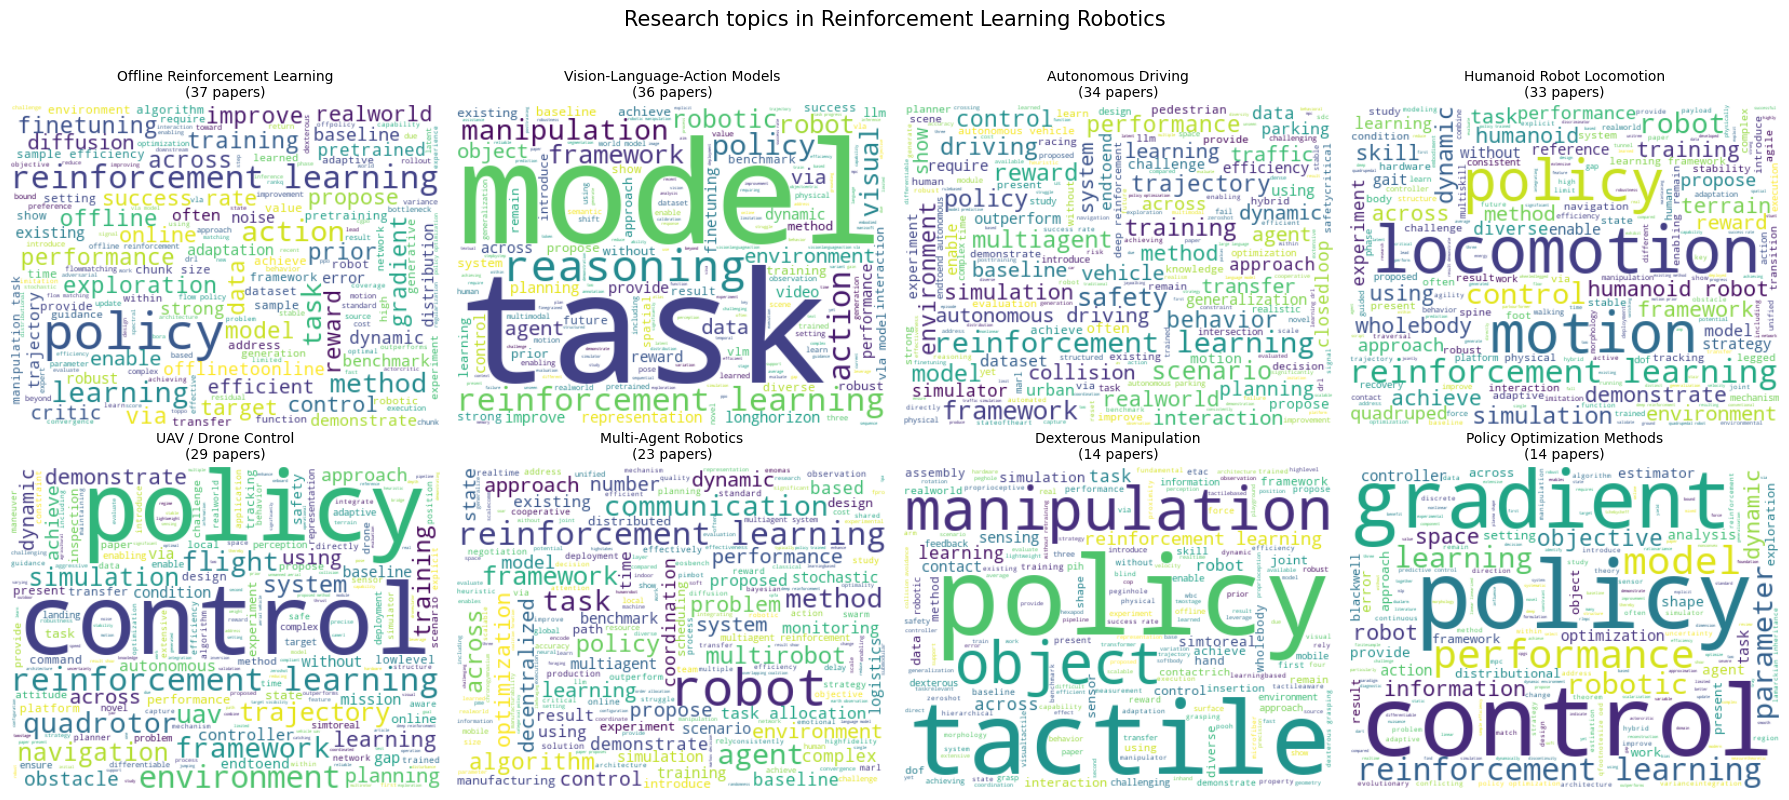

In [10]:
# Cell — word clouds for all topics with names
topics_list = sorted(df_clean['topic'].unique())
cols = 4
rows = (len(topics_list) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, topic_id in enumerate(topics_list):
    topic_papers = df_clean[df_clean['topic'] == topic_id]
    topic_name = topic_names[topic_id]
    all_text = " ".join(topic_papers['clean_text'].dropna().tolist())
    if all_text.strip():
        wc = WordCloud(width=400, height=300,
                      background_color='white',
                      colormap='viridis').generate(all_text)
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(topic_name + "\n(" + str(len(topic_papers)) + " papers)", fontsize=10)
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Research topics in Reinforcement Learning Robotics", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Cell — final summary of gaps
print("=" * 55)
print("   RESEARCH GAP ANALYSIS SUMMARY")
print("=" * 55)
print(f"Total papers analysed : 300")
print(f"Total topics found    : 8")
print(f"Date range            : {df_clean['year'].min()} - {df_clean['year'].max()}")
print("=" * 55)
print("\nTOP RESEARCH GAPS (most underexplored):\n")
for i, row in cluster_sizes.head(3).iterrows():
    print(f"  {int(row['topic'])+1}. {row['topic_name']}")
    print(f"     Papers: {row['paper_count']}  |  Gap score: {row['gap_score']}")
    print()
print("=" * 55)
print("\nMOST RESEARCHED TOPICS:\n")
for i, row in cluster_sizes.tail(3).iterrows():
    print(f"  - {row['topic_name']} ({row['paper_count']} papers)")

   RESEARCH GAP ANALYSIS SUMMARY
Total papers analysed : 300
Total topics found    : 8
Date range            : 2026 - 2026

TOP RESEARCH GAPS (most underexplored):

  7. Dexterous Manipulation
     Papers: 14  |  Gap score: 0.0714

  8. Policy Optimization Methods
     Papers: 14  |  Gap score: 0.0714

  6. Multi-Agent Robotics
     Papers: 23  |  Gap score: 0.0435


MOST RESEARCHED TOPICS:

  - Autonomous Driving (34 papers)
  - Vision-Language-Action Models (36 papers)
  - Offline Reinforcement Learning (37 papers)
